<a href="https://colab.research.google.com/github/aishanikar9/BWSI_Operations_Team/blob/main/SceneReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub segmentation-models-pytorch
import os, json, pathlib
import numpy as np, cv2, torch
from PIL import Image
from torchvision.transforms import v2
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
device: cpu


In [3]:
from google.colab import drive
import kagglehub

In [11]:
drive.mount('/content/drive')
path = kagglehub.dataset_download("yaroslavchyrko/rescuenet")
root = pathlib.Path(path)
val_original = list(root.rglob("val-org-img"))[0]
print("val images:", len(list(val_original.glob("*.jpg"))))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resuming download from 446693376 bytes (23019148568 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/yaroslavchyrko/rescuenet/1.archive (446693376/23465841944) bytes left.


100%|██████████| 21.9G/21.9G [04:21<00:00, 88.2MB/s]

Extracting files...


val images: 449


In [5]:
image_height, image_width = 160, 256 #same dimensions as other
class_number = 12

CLASS_NAMES = {0:"Background",1:"Water",2:"No Damage",3:"Minor Damage",4:"Major Damage",
               5:"Total Destruction",6:"Vehicle",7:"Clear Road",8:"Blocked Road",
               9:"Tree",10:"Pool",11:"(confirm)"}
BUILDING_SEVERITY = {2:1, 3:2, 4:3, 5:4} #maps IDs to severity ranks

In [6]:
model = smp.Unet(encoder_name="resnet34", encoder_weights=None,
                 in_channels=3, classes=class_number).to(device)

CKPT = "/content/drive/MyDrive/oluj_unet_best.pth"
assert pathlib.Path(CKPT).exists(), f"trained weights not at {CKPT} — train and save first"
model.load_state_dict(torch.load(CKPT, map_location=device)["state_dict"])
model.eval()
print("Segmentation Loaded")

Segmentation Loaded


In [7]:
!pip install -q anthropic
import os
from google.colab import userdata
os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY") #put my API key in here

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.6 MB/s eta 0:00:00


In [8]:
infer_tf = v2.Compose([
    v2.Resize((image_height, image_width)), #resizes to chosen dimensions
    v2.ToImage(), #converts PIL to Pytorch tensor
    v2.ToDtype(torch.float32, scale=True), #rescales pixels to floats between 0 to 1.0
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #same normalization seen in segmentation for the ImageNet encoder
])

def predict_masks(model, image): #returns predicted segmentaiton masks
    model.eval()
    x = infer_tf(image).unsqueeze(0).to(device) #preprocesses the image using function above, unsqueeze adds batch dimension
    with torch.no_grad(): #no gradient needed since we're only predicting, not training.
        return model(x).argmax(1)[0].cpu().numpy()

def damage_summary(mask): #returns the class name and the percent of the image the class takes up
    ids, counts = np.unique(mask, return_counts=True) #finds every distinct value in the mask, sine return_counts is true it also returns how many times each appears
    return {CLASS_NAMES[int(i)]: round(100 * int(c) / mask.size, 1) for i, c in zip(ids, counts)}

def worst_damage(mask):
    for c in (5, 4, 3, 2):     #loops through damage levels from worst to best
        y, x = np.where(mask == c) #finds all the pixels belonging to the damage class
        if len(x): #if any pixel exist this is the worst class present
            return {"class": CLASS_NAMES[c], "pixels": int(len(x)),
                    "center": (int(x.mean()), int(y.mean()))} #this reports the name, size, and center of the highest damage
    return None #else, no damage in the whole image.

def narrate(worst, summary, scene):
    from anthropic import Anthropic
    facts = {"scene": scene, "worst_damage": worst, "damage_percent": summary}
    client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    msg = client.messages.create(
        model="claude-sonnet-4-5", max_tokens=400,
        messages=[{"role": "user", "content":
            "You are a disaster-response analyst. From this aerial-damage analysis, write 3-4 "
            "sentences for a search-and-rescue team: where the worst damage is, its severity, "
            "and a recommended action.\n\n" + json.dumps(facts, indent=2)}])
    return msg.content[0].text

In [16]:
import matplotlib.pyplot as plt
import textwrap

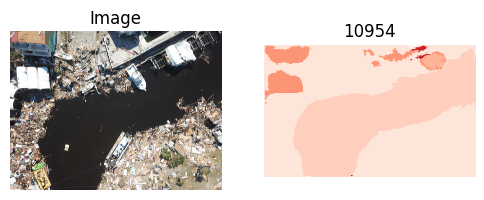

**SEARCH-AND-RESCUE BRIEF - Scene 10954:**  The worst damage is classified as "Major Damage" located
at grid coordinates [55, 27], affecting a significant concentrated area of 2,414 pixels. Overall,
5.9% of the scene shows major damage with an additional 1.0% showing minor damage, while 56.4% of
the area is inundated with water, indicating likely flooding conditions. **Immediate action
recommended:** Prioritize search-and-rescue operations at coordinates [55, 27] for potential trapped
survivors, and deploy water-capable rescue assets due to extensive flooding throughout the scene.


In [19]:
img_path = sorted(val_original.glob("*.jpg"))[11]
image = Image.open(img_path).convert("RGB")

pred = predict_masks(model, image) #runs the image through my pretrained model
worst = worst_damage(pred)   #scans the predicted mask for the most severe damage class availible
report = narrate(worst, damage_summary(pred), img_path.stem)   #claude generates the report

fig, ax = plt.subplots(1, 2, figsize=(6, 6))
ax[0].imshow(image);                                 ax[0].set_title("Image");         ax[0].axis("off")
ax[1].imshow(pred, cmap="Reds", vmin=0, vmax=11);   ax[1].set_title("Predicted mask"); ax[1].axis("off")
plt.title(img_path.stem)
plt.axis("off")
plt.show()
print(textwrap.fill(report, width=100)) #text wrap so it doesn't yap for a whole line